Dataset Loaded Successfully

First 5 Records
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  

Last 5 Records
                                                   title  \
23476  McPain: John

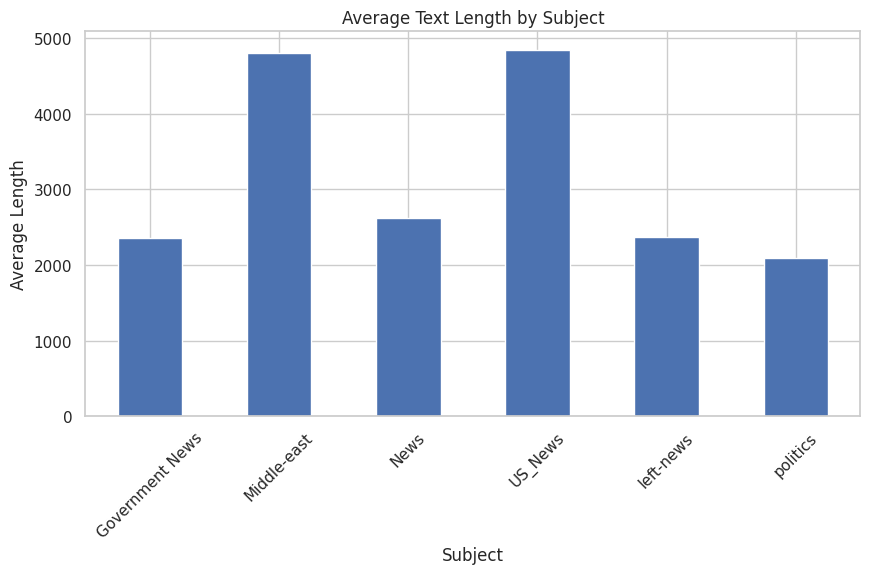


Summary
                 Average_Length  Minimum_Length  Maximum_Length  Total_News
subject                                                                    
Government News     2352.573885               1           27468        1570
Middle-east         4799.847044             142           51794         778
News                2622.963646             260           26734        9050
US_News             4847.337165             142           51794         783
left-news           2370.988562               1           49705        4459
politics            2087.715977               1           49705        6841

Numeric Columns
Index(['text_length'], dtype='object')

Only one numeric column found.
Correlation matrix cannot be computed.


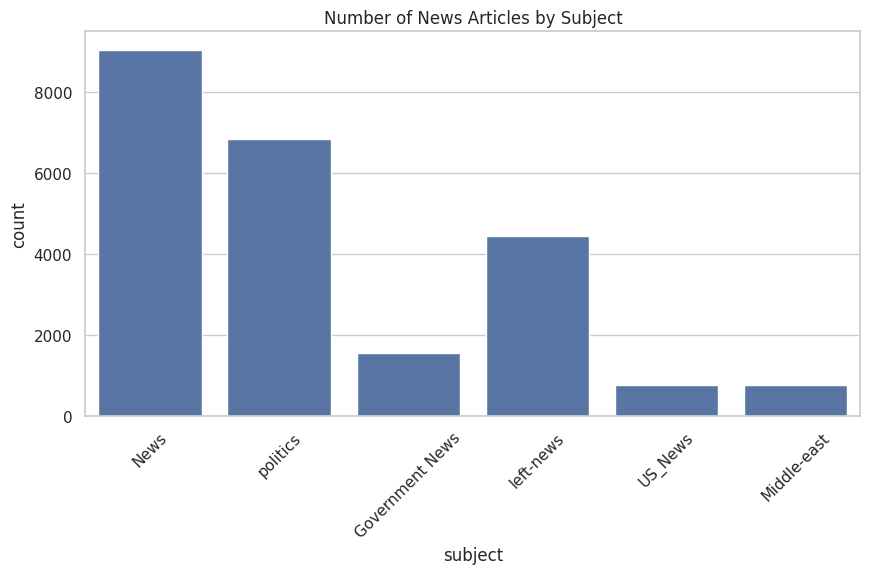

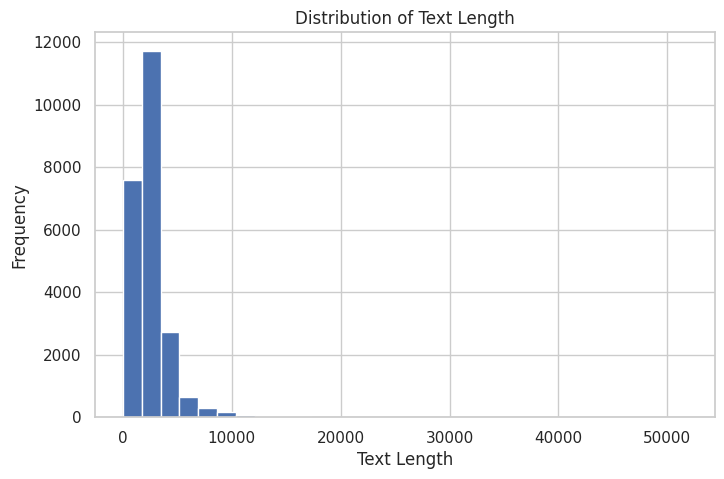

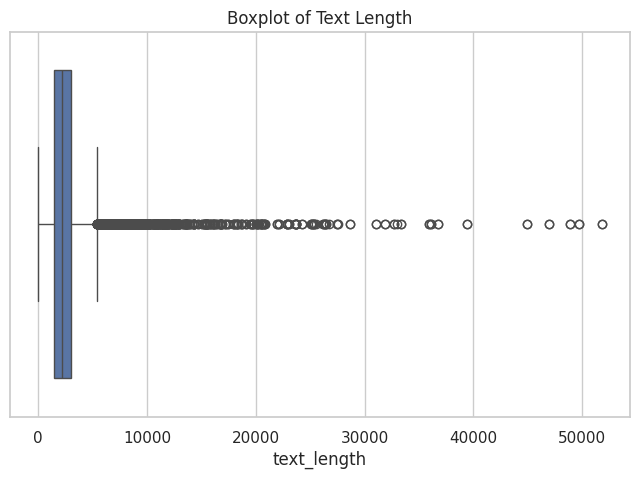


Experiment Completed Successfully.


In [7]:
# ============================================================
# EXPERIMENT 4
# DATA INSPECTION, FILTERING, STATISTICAL ANALYSIS, CORRELATION
# FAKE NEWS DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("/content/Fake.csv.zip")      # Change to your filename if needed

print("Dataset Loaded Successfully")

# ============================================================
# PROGRAM 1 - DATA INSPECTION
# ============================================================

print("\nFirst 5 Records")
print(df.head())

print("\nLast 5 Records")
print(df.tail())

# ============================================================
# PROGRAM 2 - SHAPE
# ============================================================

print("\nShape of Dataset")
print(df.shape)

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

# ============================================================
# PROGRAM 3 - COLUMN NAMES
# ============================================================

print("\nColumn Names")
print(df.columns)

# ============================================================
# PROGRAM 4 - DATA TYPES
# ============================================================

print("\nData Types")
print(df.dtypes)

print("\nDataset Information")
print(df.info())

# ============================================================
# PROGRAM 5 - MISSING VALUES
# ============================================================

print("\nMissing Values")
print(df.isnull().sum())

# ============================================================
# PROGRAM 6 - FILTER NEWS BY SUBJECT
# ============================================================

print("\nAvailable Subjects")
print(df["subject"].unique())

subject_name = df["subject"].iloc[0]

filtered = df[df["subject"] == subject_name]

print(f"\nNews from Subject : {subject_name}")
print(filtered.head())

# ============================================================
# PROGRAM 7 - TEXT LENGTH
# ============================================================

df["text_length"] = df["text"].astype(str).apply(len)

print("\nText Length Added Successfully")

# ============================================================
# PROGRAM 8 - SORT BY TEXT LENGTH
# ============================================================

sorted_df = df.sort_values(by="text_length", ascending=False)

print("\nTop 10 Longest News Articles")
print(sorted_df[["title", "subject", "text_length"]].head(10))

# ============================================================
# PROGRAM 9 - STATISTICAL ANALYSIS
# ============================================================

print("\nMean :", df["text_length"].mean())
print("Median :", df["text_length"].median())
print("Mode :")
print(df["text_length"].mode())
print("Standard Deviation :", df["text_length"].std())
print("Minimum :", df["text_length"].min())
print("Maximum :", df["text_length"].max())

# ============================================================
# PROGRAM 10 - DESCRIPTIVE STATISTICS
# ============================================================

print("\nDescriptive Statistics")
print(df["text_length"].describe())

# ============================================================
# PROGRAM 11 - GROUPING
# ============================================================

group = df.groupby("subject")["text_length"].mean()

print("\nAverage Text Length by Subject")
print(group)

plt.figure(figsize=(10,5))
group.plot(kind="bar")
plt.title("Average Text Length by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Length")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# PROGRAM 12 - AGGREGATION
# ============================================================

summary = df.groupby("subject").agg(
    Average_Length=("text_length","mean"),
    Minimum_Length=("text_length","min"),
    Maximum_Length=("text_length","max"),
    Total_News=("text_length","count")
)

print("\nSummary")
print(summary)

# ============================================================
# PROGRAM 13 - CORRELATION
# ============================================================

numeric = df.select_dtypes(include=np.number)

print("\nNumeric Columns")
print(numeric.columns)

if len(numeric.columns) > 1:
    corr = numeric.corr()

    print("\nCorrelation Matrix")
    print(corr)

    plt.figure(figsize=(6,5))
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("\nOnly one numeric column found.")
    print("Correlation matrix cannot be computed.")

# ============================================================
# PROGRAM 14 - SUBJECT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="subject")
plt.title("Number of News Articles by Subject")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# PROGRAM 15 - HISTOGRAM
# ============================================================

plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=30)
plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

# ============================================================
# PROGRAM 16 - BOXPLOT
# ============================================================

plt.figure(figsize=(8,5))
sns.boxplot(x=df["text_length"])
plt.title("Boxplot of Text Length")
plt.show()

print("\nExperiment Completed Successfully.")